#### Simulation and synthesizing controllers based on the SC3 obtained via SOS.

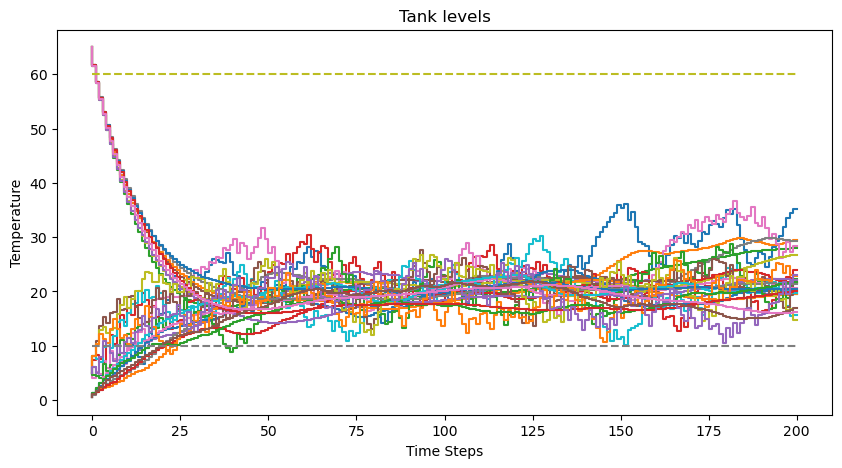

In [33]:
import numpy as np
from itertools import product
import matplotlib.pyplot as plt

n = 3 # dimension of sys
U = [0.0, 1.5, 4.5, 7.5, 9.0] # control inputs

D = {
("q0", "q1", "b", "cf"): lambda x1, x2, x3, x4, x5, x6, x7, x8, y1, y2, y3, y4, y5, y6, y7, y8:0.71 - 1.19*y8 - 0.68*y7 - 1.31*y6 - 0.56*y5 - 1.23*y4 - 0.6*y3 - 0.66*y2 - 0.63*y1 - 1.3*x3 - 2.18*x2 - 2.21*x1,
("q1", "q0", "a", "c"): lambda x1, x2, x3, x4, x5, x6, x7, x8, y1, y2, y3, y4, y5, y6, y7, y8:0.83 - 0.8*y8 - 1.05*y7 - 0.97*y6 - 0.89*y5 + 0.02*y4 - 0.41*y3 - 0.49*y2 - 0.01*y1 - 0.97*x3 - 1.8*x2 - 2.27*x1,
("q0", "q1", "cf"): lambda x1, x2, x3, x4, x5, x6, x7, x8, y1, y2, y3, y4, y5, y6, y7, y8:12.1 - 0.24*y8 + 0.1*y7 - 0.17*y6 + 0.03*y5 + 0.79*y4 - 0.13*y3 - 0.09*y2 + 0.39*y1 - 0.22*x7 - 0.23*x5 + 0.75*x3 + 0.74*x2 - 0.18*x1,
("q0", "q1", "c"): lambda x1, x2, x3, x4, x5, x6, x7, x8, y1, y2, y3, y4, y5, y6, y7, y8:12.36 - 0.28*y8 + 0.11*y7 - 0.25*y6 + 0.08*y5 + 0.74*y4 - 0.15*y3 - 0.13*y2 + 0.36*y1 - 1.89*x7 - 1.89*x5 + 0.44*x3 + 0.67*x2 + 0.06*x1,
(1, "q0", "q0", "v"): lambda x1, x2, x3, x4, x5, x6, x7, x8, y1, y2, y3, y4, y5, y6, y7, y8:0.29 + 0.53*x03 + 0.19*x02 + 0.17*x01 + 0.01*y7 + 0.01*y5 + 0.06*y3 + 0.11*y2 + 0.12*y1,
("q0", "q1", "b", "c"): lambda x1, x2, x3, x4, x5, x6, x7, x8, y1, y2, y3, y4, y5, y6, y7, y8:-0.04 - 1.1*y8 - 0.76*y7 - 1.27*y6 - 0.59*y5 - 2.69*y4 - 0.56*y3 - 0.64*y2 - 1.37*y1 - 0.68*x3 - 1.53*x2 - 0.78*x1,
("q1", "q0", "c"): lambda x1, x2, x3, x4, x5, x6, x7, x8, y1, y2, y3, y4, y5, y6, y7, y8:12.1 - 0.24*y8 + 0.1*y7 - 0.19*y6 + 0.03*y5 + 0.78*y4 - 0.13*y3 - 0.1*y2 + 0.38*y1 - 0.22*x7 - 0.23*x5 + 0.75*x3 + 0.74*x2 - 0.18*x1,
("q0", "q0", "a", "c"): lambda x1, x2, x3, x4, x5, x6, x7, x8, y1, y2, y3, y4, y5, y6, y7, y8:0.83 - 0.8*y8 - 1.05*y7 - 0.97*y6 - 0.88*y5 - 0.41*y3 - 0.5*y2 - 0.01*y1 - 0.96*x3 - 1.8*x2 - 2.26*x1,
("q1", "q1", "b", "cf"): lambda x1, x2, x3, x4, x5, x6, x7, x8, y1, y2, y3, y4, y5, y6, y7, y8:0.71 - 1.19*y8 - 0.68*y7 - 1.31*y6 - 0.56*y5 - 1.24*y4 - 0.6*y3 - 0.67*y2 - 0.63*y1 - 1.3*x3 - 2.18*x2 - 2.21*x1,
("q1", "q1", "cf"): lambda x1, x2, x3, x4, x5, x6, x7, x8, y1, y2, y3, y4, y5, y6, y7, y8:0.0,
(1, "q0", "q1", "v"): lambda x1, x2, x3, x4, x5, x6, x7, x8, y1, y2, y3, y4, y5, y6, y7, y8:0.98 + 1.85*x7 + 1.85*x5 + 0.93*x3 + 1.87*x2 + 1.86*x1,
("q1", "q0", "a", "cf"): lambda x1, x2, x3, x4, x5, x6, x7, x8, y1, y2, y3, y4, y5, y6, y7, y8:0.0,
("q0", "q0", "c"): lambda x1, x2, x3, x4, x5, x6, x7, x8, y1, y2, y3, y4, y5, y6, y7, y8:12.33 - 0.28*y8 + 0.11*y7 - 0.25*y6 + 0.08*y5 + 0.74*y4 - 0.15*y3 - 0.13*y2 + 0.36*y1 - 1.89*x7 - 1.89*x5 + 0.44*x3 + 0.67*x2 + 0.06*x1,
("q1", "q1", "b", "c"): lambda x1, x2, x3, x4, x5, x6, x7, x8, y1, y2, y3, y4, y5, y6, y7, y8:0.49 - 0.91*y8 - 0.95*y7 - 1.08*y6 - 0.78*y5 - 1.6*y4 - 0.46*y3 - 0.55*y2 - 0.82*y1 - 0.78*x3 - 1.63*x2 - 1.34*x1,
("q1", "q0", "cf"): lambda x1, x2, x3, x4, x5, x6, x7, x8, y1, y2, y3, y4, y5, y6, y7, y8:0.0,
("q0", "q0", "a", "cf"): lambda x1, x2, x3, x4, x5, x6, x7, x8, y1, y2, y3, y4, y5, y6, y7, y8:0.7 - 1.19*y8 - 0.68*y7 - 1.31*y6 - 0.56*y5 - 1.24*y4 - 0.6*y3 - 0.67*y2 - 0.63*y1 - 1.3*x3 - 2.17*x2 - 2.21*x1,
("q1", "q1", "c"): lambda x1, x2, x3, x4, x5, x6, x7, x8, y1, y2, y3, y4, y5, y6, y7, y8:12.12 - 0.24*y8 + 0.09*y7 - 0.18*y6 + 0.03*y5 + 0.79*y4 - 0.13*y3 - 0.1*y2 + 0.38*y1 - 0.22*x7 - 0.23*x5 + 0.75*x3 + 0.74*x2 - 0.18*x1,
("q0", "q0", "cf"): lambda x1, x2, x3, x4, x5, x6, x7, x8, y1, y2, y3, y4, y5, y6, y7, y8:12.07 - 0.24*y8 + 0.1*y7 - 0.17*y6 + 0.03*y5 + 0.79*y4 - 0.13*y3 - 0.09*y2 + 0.38*y1 - 0.22*x7 - 0.23*x5 + 0.75*x3 + 0.74*x2 - 0.18*x1
}

tau, gamma, lamda, delta, tau1, tau2, tau3 = 0.5, 0.85, 125.0, 1.0, 0.2, 0.0025, 0.005 # SC3 constants and S-procedure constants

a, b1, b2, b = 0.0, 10.0, 60.0, 100.0 # state space
sig, mean = np.sqrt(0.01), 0 # Guassian noise standard deviation and mean

def dyn(x_t, u_t, str):
    if str == "w":
        noise = np.random.normal(mean, sig, size = n)   
        x1n = min(max(a, (-0.5*tau + (.25*tau**2 + x_t[0] + tau*u_t)**0.5)**2 + 0.01*noise[0]), b) 
        x2n = min(max(a, (-0.5*tau + (.25*tau**2 + x_t[1] + tau*(x1n)**0.5)**0.5)**2 + 0.01*noise[0]), b) 
        x3n = min(max(a, (-0.5*tau + (.25*tau**2 + x_t[2] + tau*(x2n)**0.5)**0.5)**2 + 0.01*noise[0]), b) 
        return [x1n, x2n, x3n]
    else:
        x1n = min(max(a, (-0.5*tau + (.25*tau**2 + x_t[0] + tau*u_t)**0.5)**2), b) 
        x2n = min(max(a, (-0.5*tau + (.25*tau**2 + x_t[1] + tau*(x1n)**0.5)**0.5)**2), b) 
        x3n = min(max(a, (-0.5*tau + (.25*tau**2 + x_t[2] + tau*(x2n)**0.5)**0.5)**2), b) 
        return [x1n, x2n, x3n]

# labelling function
def L(x):
    if all(a <= xi <= b for xi in x[0:n]):
        if all(b1 <= xi <= b2 for xi in x[0:n]):
            return 'b'
        else:
            return 'a'

S1 = {
    ("q0","b"): "q1", ("q0","a"): "q0",
    ("q1","b"): "q1", ("q1","a"): "q0"
}

pri1 = {"q0": 1, "q1": 2} # priority function    

# the controller
def kappa(x,p):
    matching_u, u_list = None, []
    lab = L(x)
    pn = S1[(p,lab)]
    for u in U:
        xn = dyn(x, u, "w/o") # without noise gives expectation
        yy1, yy2, yy3 = xn
        xx4, xx5 = np.sqrt((0.5*tau)**2+x[0]+tau*u), np.sqrt(x[0])
        xx6, xx7 = np.sqrt((0.5*tau)**2+x[1]+tau*xx5), np.sqrt(x[1])
        xx8 = np.sqrt((0.5*tau)**2+x[2]+tau*xx7)
        sc3_value = D[(p, pn, lab, "c")](x1=x[0], x2=x[1], x3=x[2], x4=xx4, x5=xx5, x6=xx6, x7=xx7, x8=xx8, y1=yy1, y2=yy2, y3=yy3, y4=xx4, y5=xx5, y6=xx6, y7=xx7, y8=xx8)
        # Check the condition of SC3
        if sc3_value <= gamma:
            u_list.append(u)
            matching_u = u_list[np.random.choice(range(len(u_list)))]
            
    return matching_u

N = 10 # of trials
num_steps = 200
time_steps = np.arange(num_steps + 1)
# a dict to contain all state run
Dic1a = {key: None for key in range(1, N)}
Dic2a = {key: None for key in range(1, N)}
Dic3a = {key: None for key in range(1, N)}
# a dict to contain all input run
Inp1a = {key: None for key in range(1, N)}

def run_trial(x0):
    states = [x0]
    p, u0 = "q0", 0
    inputs = [u0]
    # Simulate the system and record inputs
    for t in range(num_steps):
        # Get input from the control policy    
        u_t = kappa(states[t],p)
        p = S1[(p,L(states[t]))]
        # Store the input
        inputs.append(u_t)
        # Update the state using the system dynamics
        states.append(dyn(states[t], u_t, "w"))
        # print("time:",t)
    return states, inputs

for i in range(1,N+1):
    # Initial condition
    # x0 = [random.choice([0,6]), random.choice([0,6]), random.choice([60,66])]
    x0 = [5, 0.5, 65]
    states, inputs = run_trial(x0)[0], run_trial(x0)[1]
    Dic1a[i] = [entry[0] for entry in states]
    Dic2a[i] = [entry[1] for entry in states]
    Dic3a[i] = [entry[2] for entry in states]
    
    Inp1a[i] = [entry for entry in inputs]

# Plotting
plt.figure(figsize=(10, 5))
for i in range(1,N):
    x1_values = Dic1a[i]
    x2_values = Dic2a[i]
    x3_values = Dic3a[i]
    plt.step(time_steps, [x for x in x1_values])
    plt.step(time_steps, [x for x in x2_values])
    plt.step(time_steps, [x for x in x3_values])
plt.step(time_steps, [b1 for h in range(len(time_steps))], where='post', linestyle='dashed')
plt.step(time_steps, [b2 for h in range(len(time_steps))], where='post', linestyle='dashed')

# # Adjust spines
# ax = plt.gca()
# ax.spines['left'].set_position(('data', 0))
# ax.spines['bottom'].set_position(('data', 0))
# ax.spines['right'].set_color('none')
# ax.spines['top'].set_color('none')


plt.title('Tank levels')
plt.xlabel('Time Steps')
plt.ylabel('Temperature')
plt.show()

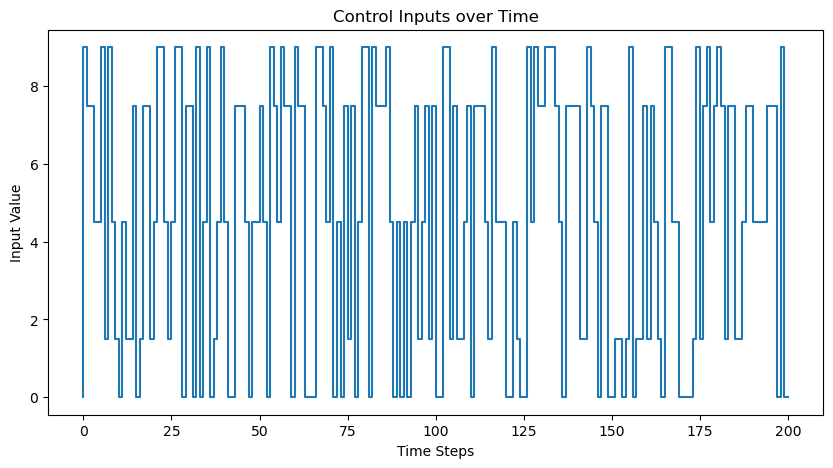

In [19]:
plt.figure(figsize=(10, 5))
for i in range(1,2):
    u1_values = Inp1a[i]
    plt.step(time_steps, [x for x in u1_values])

plt.title('Control Inputs over Time')
plt.xlabel('Time Steps')
plt.ylabel('Input Value')
plt.show()